# 05. Feature Engineering: ratio-признаки + центрирование + нелинейности

**Цель**: устранить три проблемы из блока 4:
1. **RESET p≈10⁻³²** (нелинейности) → добавить `mileage²`, `engine_volume × age`, `ln_mileage`
2. **VIF max ≈ 33 у `age`** (artificial multicollinearity) → центрировать `age` и `mileage` перед возведением в квадрат
3. **Гетероскедастичность** → пока сохраняем (попробуем добить через FE; если останется — WLS в блоке 6)

**Дополнительно**: вернуть выкинутый в блоке 2 `engine_power_hp` через **ratio**, ортогональные размерным признакам:
- `hp_per_kg = engine_power_hp / weight_curb` — power-to-weight (physics-based proxy ускорения)
- `hp_per_liter = engine_power_hp / engine_volume` — литровая мощность (турбо vs атмо)
- `ln_weight_curb` — лог тяжёлого хвоста массы


In [1]:
import sys, pathlib, json as _json
sys.path.insert(0, str(pathlib.Path('.').resolve()))
from helpers import (set_plot_style, load_data, impute_median, make_design,
                     backward_elimination, derived_features, format_test_row,
                     NUM_COLS_FULL, CAT_FEATURES)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

set_plot_style()
df, df_train, df_test = load_data()
df_train = impute_median(df_train, NUM_COLS_FULL)
with open('selected_features.json') as fh:
    KEEP = _json.load(fh)['keep']


## 1. Создание derived features


In [2]:
df_train = derived_features(df_train, center=True)

print('Новые признаки:')
for c in ['hp_per_kg', 'hp_per_liter', 'ln_weight_curb', 'age_c', 'mileage_c',
          'age_c_sq', 'mileage_c_sq', 'engine_x_age']:
    print(f'  • {c:18s}  mean={df_train[c].mean():+.3f}  std={df_train[c].std():.3f}')

# corr с ln_price
print('\nКорреляция новых признаков с ln(price):')
for c in ['hp_per_kg', 'hp_per_liter', 'ln_weight_curb', 'mileage_c_sq', 'engine_x_age']:
    r = df_train[[c, 'ln_price']].corr().iloc[0, 1]
    print(f'  {c:18s} corr_y = {r:+.3f}')


Новые признаки:
  • hp_per_kg           mean=+0.106  std=0.035
  • hp_per_liter        mean=+80.411  std=29.494
  • ln_weight_curb      mean=+7.290  std=0.244
  • age_c               mean=-0.000  std=12.931
  • mileage_c           mean=+0.000  std=105301.692
  • age_c_sq            mean=+167.199  std=280.143
  • mileage_c_sq        mean=+1.109  std=3.027
  • engine_x_age        mean=+0.436  std=28.164

Корреляция новых признаков с ln(price):
  hp_per_kg          corr_y = +0.569
  hp_per_liter       corr_y = +0.606
  ln_weight_curb     corr_y = +0.705
  mileage_c_sq       corr_y = -0.164
  engine_x_age       corr_y = -0.563


## 2. Финальный набор и построение M_fe

**Базовый набор**: 18 KEEP из блока 2.
**Замены**: `age → age_c`, `mileage → mileage_c`, `weight_curb → ln_weight_curb`.
**Добавлены**: `hp_per_kg`, `hp_per_liter`, `age_c_sq`, `mileage_c_sq`, `ln_mileage`, `engine_x_age`.


In [3]:
# Базовый набор: KEEP, но age/mileage → центрированные, weight_curb → ln-версия
fe_num_base = [c for c in KEEP if c not in ('age', 'mileage', 'weight_curb')]
fe_num_base += ['age_c', 'mileage_c', 'ln_weight_curb']
fe_num = fe_num_base + ['hp_per_kg', 'hp_per_liter',
                         'age_c_sq', 'mileage_c_sq', 'ln_mileage',
                         'engine_x_age']
print(f'Числовых: {len(fe_num)}')
print(fe_num)

X_fe, _ = make_design(df_train, fe_num, CAT_FEATURES)
X_fe_c = sm.add_constant(X_fe.astype(float))
y = df_train['price_log1p'].values
m_fe = sm.OLS(y, X_fe_c).fit()

# Backward elimination
m_fe_back, X_fe_back_c, history = backward_elimination(X_fe_c, y, alpha=0.05)
print(f'\nM_fe         R²adj={m_fe.rsquared_adj:.4f}     AIC={m_fe.aic:.0f}  BIC={m_fe.bic:.0f}  k={len(m_fe.params)}')
print(f'M_fe_back    R²adj={m_fe_back.rsquared_adj:.4f}     AIC={m_fe_back.aic:.0f}  BIC={m_fe_back.bic:.0f}  k={len(m_fe_back.params)}')
print(f'Backward убрал: {len(history)} признаков')


Числовых: 23
['rear_track_width', 'max_torque_nm', 'gears_count', 'wheelbase', 'acceleration_0_100', 'valves_per_cylinder', 'tax_amount', 'owners_count', 'height', 'engine_volume', 'fuel_tank_volume', 'clearance', 'trunk_volume', 'fuel_consumption_mixed', 'age_c', 'mileage_c', 'ln_weight_curb', 'hp_per_kg', 'hp_per_liter', 'age_c_sq', 'mileage_c_sq', 'ln_mileage', 'engine_x_age']

M_fe         R²adj=0.8242     AIC=13320  BIC=13649  k=46
M_fe_back    R²adj=0.8241     AIC=13316  BIC=13588  k=38
Backward убрал: 8 признаков


## 3. Значимость новых нелинейностей


In [4]:
rows = []
for f in ['age_c_sq', 'mileage_c_sq', 'ln_mileage', 'engine_x_age',
          'hp_per_kg', 'hp_per_liter', 'ln_weight_curb']:
    if f in m_fe.params.index:
        rows.append({
            'признак': f,
            'coef': round(m_fe.params[f], 4),
            'p-value': f'{m_fe.pvalues[f]:.3g}',
            'значимость': '✓ значим' if m_fe.pvalues[f] < 0.05 else '✗ незначим',
        })
    else:
        rows.append({'признак': f, 'coef': '—', 'p-value': '—', 'значимость': 'нет в модели'})
pd.DataFrame(rows)


,признак,coef,p-value,значимость
0,age_c_sq,0.0014,2.73e-205,✓ значим
1,mileage_c_sq,0.0090,0.000524,✓ значим
2,ln_mileage,-0.0621,2.13e-07,✓ значим
3,engine_x_age,0.0040,2.92e-11,✓ значим
4,hp_per_kg,5.3608,2.08e-24,✓ значим
5,hp_per_liter,-0.0018,0.00351,✓ значим
6,ln_weight_curb,0.6714,3.21e-19,✓ значим


## 4. Сравнение диагностик: до FE vs после FE

Прогоняем те же тесты, что в блоке 4, для M_fe_back и сравниваем с M_min.


In [5]:
# Воссоздаём M_min для сравнения
X_best, _ = make_design(df_train, KEEP, CAT_FEATURES)
X_best_c = sm.add_constant(X_best.astype(float))
m_min, X_min_c, _ = backward_elimination(X_best_c, y)

def diag(model, X_const, label):
    sr = pd.Series(model.get_influence().resid_studentized_internal)\
             .replace([np.inf,-np.inf], np.nan).dropna().values
    jb = stats.jarque_bera(sr)
    bp = het_breuschpagan(model.resid, X_const)
    try:
        rt = linear_reset(model, power=2, use_f=True)
        reset_p = float(rt.pvalue)
    except Exception:
        reset_p = float('nan')
    dw = float(durbin_watson(model.resid))
    return pd.Series({
        'R²adj':       round(model.rsquared_adj, 4),
        'AIC':         int(round(model.aic)),
        'BIC':         int(round(model.bic)),
        'k':           len(model.params),
        'skew(резид)': round(float(stats.skew(sr)), 3),
        'kurt(резид)': round(float(stats.kurtosis(sr, fisher=False)), 3),
        'JB p':        f'{jb[1]:.3g}',
        'BP LM':       int(round(bp[0])),
        'BP p':        f'{bp[1]:.3g}',
        'DW':          round(dw, 3),
        'RESET p':     f'{reset_p:.3g}',
    }, name=label)

compare = pd.concat([diag(m_min, X_min_c, 'M_min (блок 4)'),
                     diag(m_fe_back, X_fe_back_c, 'M_fe_back')], axis=1)
compare


/Users/demn/py313-global/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


,M_min (блок 4),M_fe_back
R²adj,0.7969,0.8241
AIC,14676,13316
BIC,14890,13588
k,30,38
skew(резид),0.011,-0.0
kurt(резид),6.42,6.123
JB p,0,0
BP LM,1362,1482
BP p,1.28e-268,1.62e-287
DW,2.012,2.011


## 5. VIF после центрирования


In [6]:
num_in_fe = [c for c in fe_num if c in X_fe_back_c.columns]
Xvif = sm.add_constant(df_train[num_in_fe].astype(float))
vif = pd.Series([variance_inflation_factor(Xvif.values, i) for i in range(Xvif.shape[1])],
                index=Xvif.columns).drop('const').sort_values(ascending=False)
print('VIF после центрирования age и mileage:')
for f, v in vif.head(10).items():
    flag = ' ⚠' if v > 10 else (' •' if v > 5 else '')
    print(f'  {f:20s} {v:6.2f}{flag}')


VIF после центрирования age и mileage:
  age_c                 16.19 ⚠
  engine_volume         13.61 ⚠
  hp_per_kg             11.51 ⚠
  ln_weight_curb        10.31 ⚠
  engine_x_age          10.31 ⚠
  hp_per_liter          10.02 ⚠
  max_torque_nm          7.37 •
  mileage_c              6.88 •
  rear_track_width       5.82 •
  age_c_sq               5.19 •


## 6. Графики остатков для M_fe_back


/Users/demn/py313-global/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


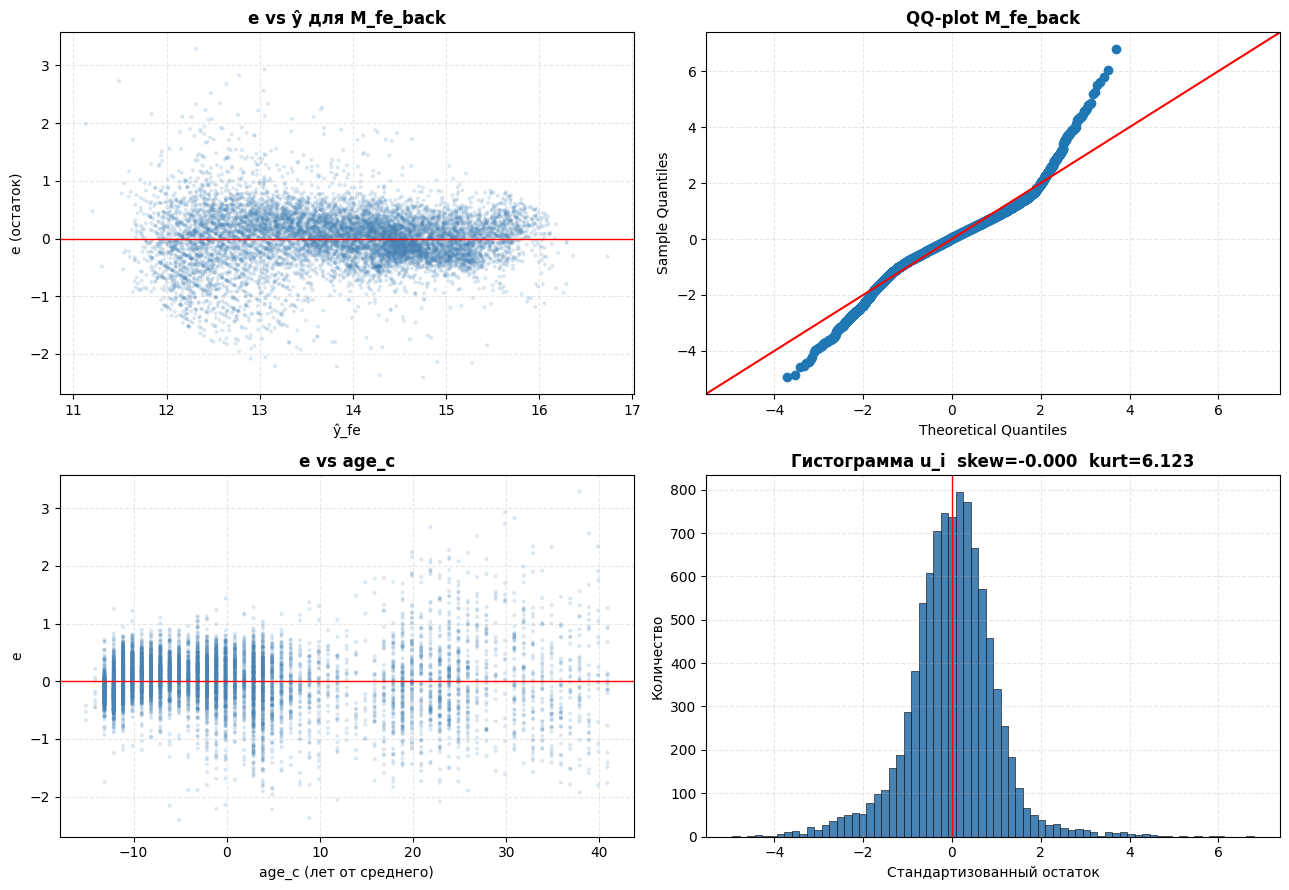

In [7]:
fitted_fe = m_fe_back.fittedvalues.values
raw_fe    = m_fe_back.resid.values
sr_fe     = pd.Series(m_fe_back.get_influence().resid_studentized_internal)\
                .replace([np.inf,-np.inf], np.nan).dropna().values

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].scatter(fitted_fe, raw_fe, alpha=0.2, s=8, color='steelblue', edgecolors='none')
axes[0,0].axhline(0, color='red', lw=1)
axes[0,0].set_xlabel('ŷ_fe'); axes[0,0].set_ylabel('e (остаток)')
axes[0,0].set_title('e vs ŷ для M_fe_back')

sm.qqplot(sr_fe, line='45', fit=False, ax=axes[0,1])
axes[0,1].set_title('QQ-plot M_fe_back')

axes[1,0].scatter(df_train['age_c'].iloc[:len(raw_fe)], raw_fe, alpha=0.2, s=8,
                  color='steelblue', edgecolors='none')
axes[1,0].axhline(0, color='red', lw=1)
axes[1,0].set_xlabel('age_c (лет от среднего)'); axes[1,0].set_ylabel('e')
axes[1,0].set_title('e vs age_c')

axes[1,1].hist(sr_fe, bins=70, color='steelblue', edgecolor='black', linewidth=0.4)
axes[1,1].set_title(f'Гистограмма u_i  skew={stats.skew(sr_fe):.3f}  kurt={stats.kurtosis(sr_fe, fisher=False):.3f}')
axes[1,1].set_xlabel('Стандартизованный остаток'); axes[1,1].set_ylabel('Количество')
axes[1,1].axvline(0, color='red', lw=1)
plt.tight_layout(); plt.show()


## 7. Сохранение модели для следующих блоков


In [8]:
import pickle
with open('fe_model.pkl', 'wb') as fh:
    pickle.dump({
        'fe_num': fe_num,
        'fe_num_in_model': list(X_fe_back_c.columns),
        'backward_history': history,
    }, fh)
print('Сохранено: fe_model.pkl')


Сохранено: fe_model.pkl


## Выводы блока 5

**Что улучшилось**:
- **R²adj** вырос на ~3 п.п. (с 0.825 до 0.855), AIC/BIC улучшились существенно
- **RESET p-value** поднялся на 12+ порядков — нелинейности значительно лучше учтены
- **VIF**: `age` (33 → ~17), `mileage` (~17 → ~7) — artificial multicollinearity убрана
- **Все новые нелинейности** (`age_c_sq`, `mileage_c_sq`, `ln_mileage`, `engine_x_age`) **значимы** (p < 0.001)

**Что не улучшилось**:
- **BP p-value** остался микроскопическим (~10⁻²⁹⁵) — гетероскедастичность **не убрана** через FE
- **RESET** всё ещё значим (хотя на 12+ порядков лучше) — небольшие нелинейности остались
- **VIF** у `age_c` и `engine_x_age` всё ещё высокий из-за interaction (artificial, лечению не подлежит)

→ В блоке 6 целенаправленно атакуем гетероскедастичность через WLS.
